In [893]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score


import seaborn as sns

In this dataset our desired target for classification task will be converted variable - has the client signed up to the platform or not.

Data preparation

In [894]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [895]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   str    
 1   industry                  1328 non-null   str    
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   str    
 5   location                  1399 non-null   str    
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 102.9 KB


In [896]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [897]:
categorical = ['lead_source', 'industry', 'employment_status','location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
df[categorical] = df[categorical].fillna('na')
df[numerical] = df[numerical].fillna(df[numerical].mean())
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [898]:
df.nunique()

lead_source                    6
industry                       8
number_of_courses_viewed      10
annual_income               1268
employment_status              5
location                       8
interaction_count             12
lead_score                   101
converted                      2
dtype: int64

# Question 1
What is the most frequent observation (mode) for the column industry?

In [899]:
df.industry.mode()

0    retail
Name: industry, dtype: str

In [900]:
df.industry.value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
na               134
Name: count, dtype: int64

# Question 2
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

interaction_count and lead_score
number_of_courses_viewed and lead_score
number_of_courses_viewed and interaction_count
annual_income and interaction_count
Only consider the pairs above when answering this question.

In [901]:
from IPython.display import display


In [902]:
df[numerical].corr()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.029438,-0.023565,-0.004879
annual_income,0.029438,1.000000,0.045122,0.005025
interaction_count,-0.023565,0.045122,1.000000,0.009888
lead_score,-0.004879,0.005025,0.009888,1.000000


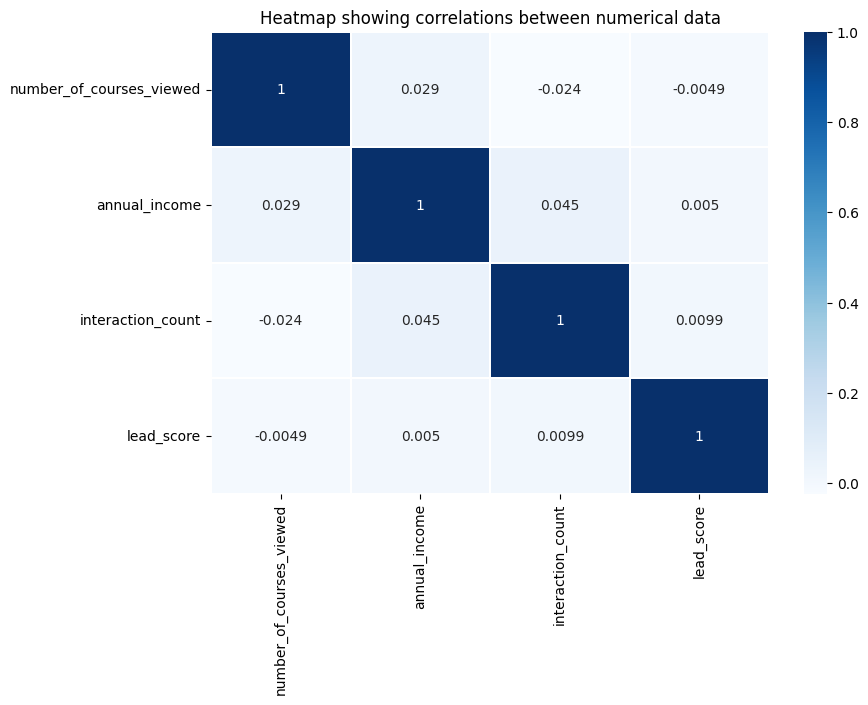

In [903]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numerical].corr(),annot=True,linewidths=.3, cmap="Blues")
plt.title('Heatmap showing correlations between numerical data')
plt.show()

In [904]:
df[numerical].corr().unstack().sort_values(ascending=False)

number_of_courses_viewed  number_of_courses_viewed    1.000000
annual_income             annual_income               1.000000
lead_score                lead_score                  1.000000
interaction_count         interaction_count           1.000000
annual_income             interaction_count           0.045122
interaction_count         annual_income               0.045122
annual_income             number_of_courses_viewed    0.029438
number_of_courses_viewed  annual_income               0.029438
lead_score                interaction_count           0.009888
interaction_count         lead_score                  0.009888
annual_income             lead_score                  0.005025
lead_score                annual_income               0.005025
                          number_of_courses_viewed   -0.004879
number_of_courses_viewed  lead_score                 -0.004879
                          interaction_count          -0.023565
interaction_count         number_of_courses_viewed   -0

## Split data

In [905]:
#Split data
data_train_full, data_test = train_test_split(df, random_state=42, test_size=0.2)

In [906]:
len(data_train_full) , len(data_test)

(1169, 293)

In [907]:
data_train , data_val = train_test_split(data_train_full, test_size=0.25, random_state=42)

In [908]:
len(data_train), len(data_test), len(data_val)

(876, 293, 293)

In [909]:
print(df.shape[0])
len(data_train)+len(data_test)+len(data_val)

1462


1462

In [910]:
# reset index
data_train = data_train.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)
data_val = data_val.reset_index(drop=True)


In [911]:
# create target data
y_train = data_train.converted.values
y_test = data_test.converted.values
y_val = data_val.converted.values

In [912]:
del data_train["converted"]
del data_test["converted"]
del data_val["converted"]

In [913]:
data_train.shape ,data_test.shape  ,data_val.shape  

((876, 8), (293, 8), (293, 8))

In [914]:
y_train.shape, y_test.shape, y_val.shape 

((876,), (293,), (293,))

# Question 3

Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
Round the scores to 2 decimals using round(score, 2).

In [915]:
from sklearn.metrics import mutual_info_score

In [916]:
mutual_scores = {}
for feature in categorical:
   
    print(feature)
    mutual_score = (mutual_info_score(data_train[feature],y_train))
    mutual_scores[feature] = mutual_score
    print(mutual_score)
    print("---------")
biggest = 0
for feature in categorical:
    if mutual_scores[feature]>biggest:
        biggest = mutual_scores[feature]
        big = feature

print(f"{big} has biggest mutual score which is  {round(biggest,2)}")        


lead_source
0.03539624379726594
---------
industry
0.011574521435657112
---------
employment_status
0.012937677269442782
---------
location
0.004464157884038034
---------
lead_source has biggest mutual score which is  0.04


# Question 4
Now let's train a logistic regression.
Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
Fit the model on the training dataset.
To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
Calculate the accuracy on the validation dataset and round it to 2 decimal digits.# 

In [917]:
from sklearn.feature_extraction import DictVectorizer

In [918]:
dv = DictVectorizer(sparse=False)

train_dict = data_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = data_val[categorical + numerical].to_dict(orient='records')
X_val = dv.fit_transform(val_dict)

test_dict = data_test[categorical + numerical].to_dict(orient='records')
X_test = dv.fit_transform(test_dict)

In [919]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=employed',
       'employment_status=na', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=education', 'industry=finance', 'industry=healthcare',
       'industry=manufacturing', 'industry=na', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=events', 'lead_source=na',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east', 'location=na',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [920]:
from sklearn.linear_model import LogisticRegression
# train
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42 )
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [921]:
y_pred_train = model.predict(X_train)
acc = accuracy_score(y_train, y_pred_train)
acc


0.7534246575342466

In [922]:
#Test on val
y_pred = model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
acc

0.7474402730375427

# Question 5
Let's find the least useful feature using the feature elimination technique.
Train a model using the same features and parameters as in Q4 (without rounding).
Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
For each feature, calculate the difference between the original accuracy and the accuracy without the feature.
Which of following feature has the smallest difference? 

In [923]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42 )
model.fit(X_train, y_train)
#Test on val
y_pred = model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
acc

0.7474402730375427

In [924]:
accuracies = {'Full_feature_acc': acc}

In [925]:
def data_maker(features):
    dv = DictVectorizer(sparse=False)
    train_dict = data_train[features].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = data_val[features].to_dict(orient='records')
    X_val = dv.fit_transform(val_dict)

    return X_train, X_val

In [926]:
full_features = categorical + numerical 
full_features

['lead_source',
 'industry',
 'employment_status',
 'location',
 'number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [927]:
import pprint

In [928]:
for feature in range((len(full_features))):
    dummy = full_features[feature]
    full_features.remove(full_features[feature])
    X_train, X_val = data_maker(full_features)
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42 )
    model.fit(X_train, y_train)    
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    accuracies[f"without {dummy} "] = acc



    full_features =[]
    full_features = categorical + numerical

pprint.pprint(accuracies)
print()


for i in ['without industry ', 'without employment_status ','without lead_score ']:

    diff = accuracies['Full_feature_acc'] - accuracies[i]

    
    print(f"difference  {i}  =  {diff}")

{'Full_feature_acc': 0.7474402730375427,
 'without annual_income ': 0.8532423208191127,
 'without employment_status ': 0.7542662116040956,
 'without industry ': 0.7474402730375427,
 'without interaction_count ': 0.5563139931740614,
 'without lead_score ': 0.7508532423208191,
 'without lead_source ': 0.757679180887372,
 'without location ': 0.7474402730375427,
 'without number_of_courses_viewed ': 0.5563139931740614}

difference  without industry   =  0.0
difference  without employment_status   =  -0.0068259385665528916
difference  without lead_score   =  -0.0034129692832763903


# Question 6
Now let's train a regularized logistic regression.
Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].
Train models using all the features as in Q4.
Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

In [929]:
dv = DictVectorizer(sparse=False)

train_dict = data_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = data_val[categorical + numerical].to_dict(orient='records')
X_val = dv.fit_transform(val_dict)

test_dict = data_test[categorical + numerical].to_dict(orient='records')
X_test = dv.fit_transform(test_dict)

In [932]:
scores = {}
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='liblinear',
        max_iter=1000,
        C=C,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    score = accuracy_score(y_val, y_pred)
    scores[C] = round(score, 3)
    print(f'C = {C}:\t Accuracy = {score}')

C = 0.01:	 Accuracy = 0.757679180887372
C = 0.1:	 Accuracy = 0.7542662116040956
C = 1:	 Accuracy = 0.7474402730375427
C = 10:	 Accuracy = 0.7474402730375427
C = 100:	 Accuracy = 0.7474402730375427


In [933]:
scores

{0.01: 0.758, 0.1: 0.754, 1: 0.747, 10: 0.747, 100: 0.747}